In [2]:
import pandas as pd

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("*-------- SIMPLE DATA SUMMARY --------*")
df.info()

print("*---------- UNCOMPLETED DATA ----------*")
df.isnull().sum()

*-------- SIMPLE DATA SUMMARY --------*
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
*---------- UNCOMPLETED DATA ----------*


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [4]:
df = df.drop(columns=["Cabin"])

mean_age = df["Age"].mean()

df["Age"] = df["Age"].fillna(mean_age)

most_pop_embarked = df["Embarked"].mode()[0]

df["Embarked"] = df["Embarked"].fillna(most_pop_embarked)

df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
df = df.drop(columns=["PassengerId", "Name", "Ticket"])
family_members = df["SibSp"] + df["Parch"]
df = df.drop(columns=["SibSp", "Parch"])
df["FamilyMembers"] = family_members

df.head()
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

df.head()

,Survived,Pclass,Sex,Age,Fare,FamilyMembers,Embarked_Q,Embarked_S
0,0,3,0,22.0,7.2500,1,False,True
1,1,1,1,38.0,71.2833,1,False,False
2,1,3,1,26.0,7.9250,0,False,True
3,1,1,1,35.0,53.1000,1,False,True
4,0,3,0,35.0,8.0500,0,False,True


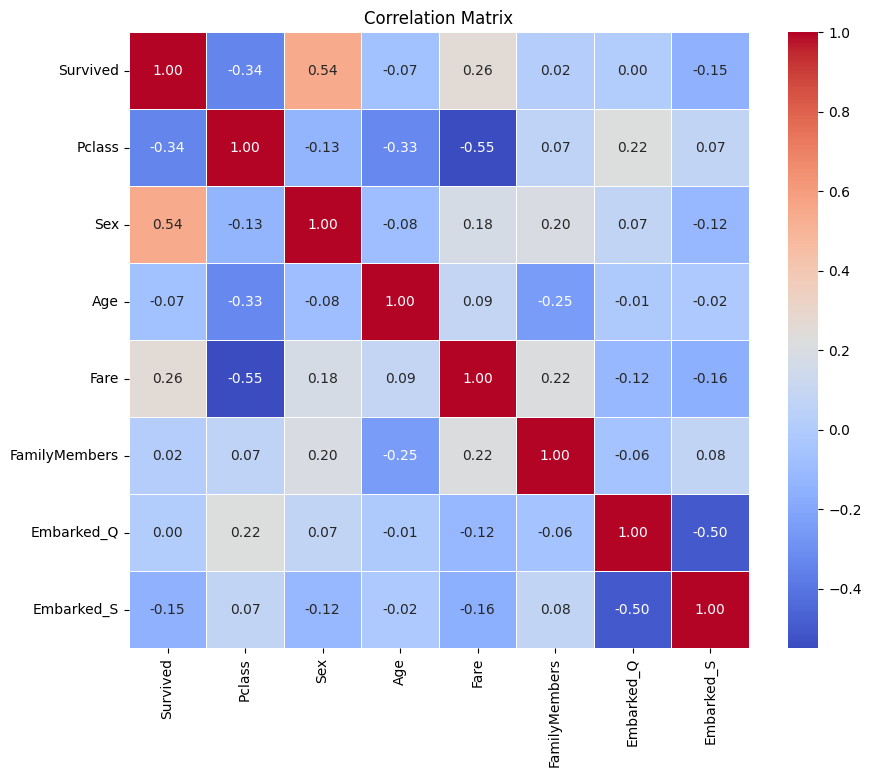

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()
plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()


In [7]:
from sklearn.model_selection import train_test_split

y = df["Survived"]
X = df.drop(columns=["Survived"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Passengers to train: {X_train.shape[0]}")
print(f"Passengers to test: {X_test.shape[0]}")

Passengers to train: 712
Passengers to test: 179


In [8]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=101, max_depth=9, random_state=42)

forest.fit(X_train, y_train)
print("Ready. Model has been trained and it ready to test")

Ready. Model has been trained and it ready to test


In [9]:
forest_predict = forest.predict(X_test)
forest_predict_proba = forest.predict_proba(X_test)

from sklearn.metrics import accuracy_score

accurecy = accuracy_score(y_test, forest_predict)

print(f"Accuracy: {accurecy * 100:.2f}%")
print(f"Survived probability of first five passengers: {forest_predict_proba[:5]}")

Accuracy: 83.80%
Survived probability of first five passengers: [[0.76616594 0.23383406]
 [0.89312986 0.10687014]
 [0.87427053 0.12572947]
 [0.01953195 0.98046805]
 [0.49536995 0.50463005]]


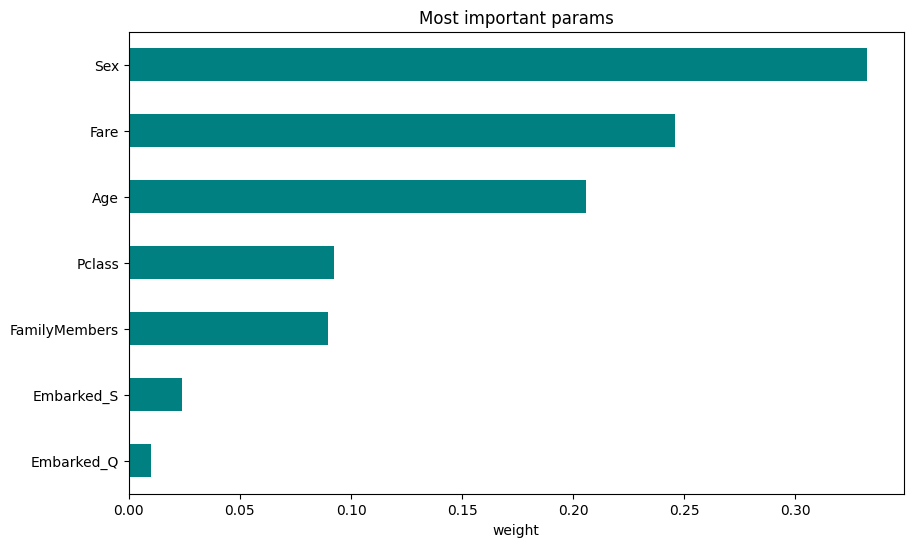

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

accuracy = pd.Series(forest.feature_importances_, index=X_train.columns)

accuracy.sort_values().plot(kind='barh', color='teal', figsize=(10, 6))

plt.title("Most important params")
plt.xlabel("weight")
plt.show()

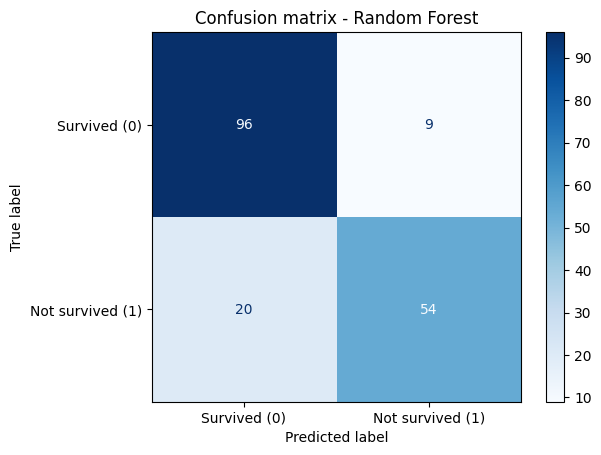

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

matrix = confusion_matrix(y_test, forest_predict)

matrix_disp = ConfusionMatrixDisplay(confusion_matrix=matrix,
                                      display_labels=['Survived (0)', 'Not survived (1)'])

matrix_disp.plot(cmap='Blues', values_format='d')

plt.title("Confusion matrix - Random Forest")
plt.show()

In [12]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

print("Ready. Model has been trained and it ready to test")

Ready. Model has been trained and it ready to test


In [13]:
model_predict = model.predict(X_test)
model_predict_proba = model.predict_proba(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, model_predict)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Survived probability of first five passengers: {model_predict_proba[:5]}")

Accuracy: 78.77%
Survived probability of first five passengers: [[1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]


In [14]:
import joblib

joblib.dump(forest, 'titanic_model.pkl')

print("Model is ready!")

Model is ready!
